## Задания по Pandas


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
import numpy as np

%matplotlib inline

Задания выполняются с датасетом Pima Indian Diabetes - это данные из Национального института диабета, болезней органов пищеварения и почек. Целью набора данных является прогнозирование наличия диабета у пациента. Все пациенты в приведенной выборке - женщины в возрасте от 21 года, индийского происхождения.

In [4]:
data = pd.read_csv('pima-indians-diabetes.csv')
data.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Class
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
5,5,116.0,74.0,NaN,NaN,25.6,0.201,30,0
6,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
7,10,115.0,NaN,NaN,NaN,35.3,0.134,29,0
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
9,8,125.0,96.0,NaN,NaN,NaN,0.232,54,1


Описание данных:

- __Pregnancies__ - количество беременностей, единицы измерения - целые числа от 0 до N. Тип переменной - количественная, дискретная.
- __Glucose__ - уровень глюкозы в крови, единицы измерения - целые числа. Тип переменной - количественная, дискретная.
- __BloodPressure__ - артериальное давление, единицы измерения - миллиметры р/с, целые числа. Тип переменной - количественная, дискретная.
- __SkinThickness__ - обхват трицепса в миллиметрах, целые числа. Тип переменной - количественная, дискретная.
- __Insulin__ - уровень инсулина в крови, целые числа. Тип переменной - количественная, дискретная.
- __BMI__ - индекс массы тела. Тип переменной - количественная, непрерывная.
- __DiabetesPedigreeFunction__ - риск наследственного диабета в зависимости наличия диабета у родственников. Выражается десятичной дробью от 0 до 1. Тип переменной - количественная, непрерывная.
- __Age__ - возраст в целых числах. Тип переменной - количественная, дискретная.
- __Class__ - наличие диабета у субъекта, выражена 0 (здоров) или 1(болен). Тип переменной - категориальная, бинарная.

__Задание 1.__

В загруженных данных много пропусков (NaN). Любым способом посчитайте количество пропусков в каждом из столбцов.

Для тех переменных, в которых есть пропуски, выведите количество пропущенных значений в следующем формате:

"В переменной {название переменной} {количество} пропущенных значений"

In [5]:
# решение
missing_values = data.isnull().sum()
for column in missing_values[missing_values > 0].index:
    print(f"В переменной {column} {missing_values[column]} пропущенных значений")


В переменной Glucose 5 пропущенных значений
В переменной BloodPressure 35 пропущенных значений
В переменной SkinThickness 227 пропущенных значений
В переменной Insulin 374 пропущенных значений
В переменной BMI 11 пропущенных значений


__Задание 2.__

Замените все пропуски дискретных признаков соответствующими медианами, непрерывных признаков - средними значениями.

In [6]:
discrete_features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'Age']
for feature in discrete_features:
    data[feature] = data[feature].fillna(data[feature].median())

continuous_features = ['BMI', 'DiabetesPedigreeFunction']
for feature in continuous_features:
    data[feature] = data[feature].fillna(data[feature].mean())


__Задание 3.__

Выведите основные статистики (минимум, максимум, среднее, дисперсию, квантили) для всех столбцов.

In [7]:
# решение
print("\nBasic statistics for all columns:")
print(data.describe())


Basic statistics for all columns:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.656250      72.386719      29.108073  140.671875   
std       3.369578   30.438286      12.096642       8.791221   86.383060   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      25.000000  121.500000   
50%       3.000000  117.000000      72.000000      29.000000  125.000000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age       Class  
count  768.000000                768.000000  768.000000  768.000000  
mean    32.457464                  0.471876   33.240885    0.348958  
std      6.875151                  0.331329   11.760232    0.476951  


__Задание 4.__

У скольких женщин старше 50 лет обнаружен диабет?

In [8]:
# решение
women_over_50_diabetes = data[(data['Age'] > 50) & (data['Class'] == 1)].shape[0]
print(women_over_50_diabetes)


38


__Задание 5.__

Найдите трех женщин с наибольшими числом беременностей.

In [24]:
# решение
print("Три женщины с наибольшим кол-вом беременностей")
print(data.nlargest(3, 'Pregnancies')[['Pregnancies', 'Age', 'Class']])


Три женщины с наибольшим кол-вом беременностей
     Pregnancies  Age  Class
159           17   47      1
88            15   43      1
298           14   46      1


__Задание 6.__

Сколько женщин успели родить 3 или более детей до 30 лет?

In [25]:
# решение
women_3plus_before_30 = data[(data['Pregnancies'] >= 3) & (data['Age'] < 30)].shape[0]
print(f"Женщины которые успели родить 3 или более детей до 30 лет: {women_3plus_before_30}")


Женщины которые успели родить 3 или более детей до 30 лет: 117


__Задание 7.__

Нормальным кровяным давлением будем считать давление в диапазоне [80-89]. У какого процента женщин давление нормальное?

In [26]:
# решение
normal_bp = data[(data['BloodPressure'] >= 80) & (data['BloodPressure'] <= 89)].shape[0]
percentage_normal_bp = (normal_bp / data.shape[0]) * 100
print(f"Процент женщин с давлением нормальным: {percentage_normal_bp:.2f}%")


Процент женщин с давлением нормальным: 18.88%


__Задание 8.__

Считается, что BMI >= 30 - это признак ожирения.
У скольких женщин с признаками ожирения кровяное давление выше среднего?

In [28]:
# решение
avg_bp = data['BloodPressure'].mean()
obese_high_bp = data[(data['BMI'] >= 30) & (data['BloodPressure'] > avg_bp)].shape[0]
print(f"Процент женщин с ожирением и высоким давлением: {obese_high_bp}")


Процент женщин с ожирением и высоким давлением: 251


__Задание 9.__

Сравните средние значения для признаков __Glucose,	BloodPressure,	Insulin__ среди тех, у кого обнаружен диабет, и тех, у кого его нет.

In [30]:
# решение
print("Сравнение:")
features = ['Glucose', 'BloodPressure', 'Insulin']
for feature in features:
    diabetic_mean = data[data['Class'] == 1][feature].mean()
    non_diabetic_mean = data[data['Class'] == 0][feature].mean()
    print(f"\n{feature}:")
    print(f"С диабетом: {diabetic_mean:.2f}")
    print(f"Без диабета: {non_diabetic_mean:.2f}")


Сравнение:

Glucose:
С диабетом: 142.13
Без диабета: 110.68

BloodPressure:
С диабетом: 75.12
Без диабета: 70.92

Insulin:
С диабетом: 164.70
Без диабета: 127.79


__Задание 10.__

Постройте круговую диаграмму для признака __Class__.

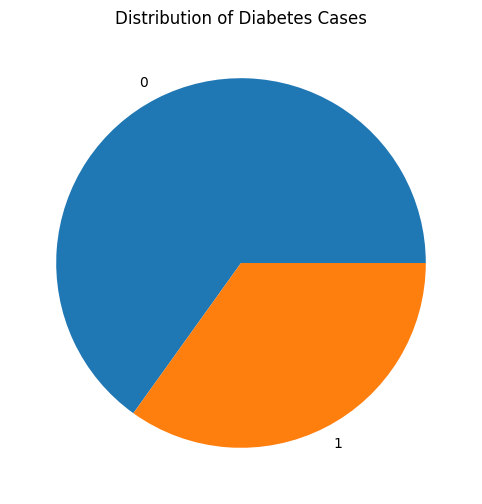

In [31]:
# решение
plt.figure(figsize=(8, 6))
data['Class'].value_counts().plot(kind='pie')
plt.title('Distribution of Diabetes Cases')
plt.ylabel('')
plt.show()


__Задание 11.__

Постройте распределение для признака __BMI__ и сравните его с нормальным (напишите вывод в новой markdown-ячейке под графиками)

Постройте нормальное распределение поверх графика.

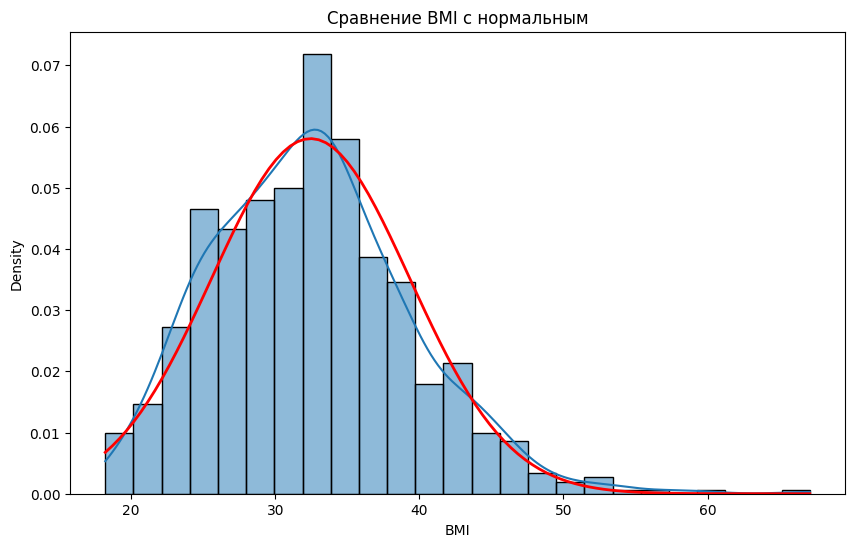

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data['BMI'], kde=True, stat='density')
x = np.linspace(data['BMI'].min(), data['BMI'].max(), 100)
plt.plot(x, norm.pdf(x, data['BMI'].mean(), data['BMI'].std()), 'r-', lw=2)
plt.title('Сравнение BMI с нормальным')
plt.show()

__Задание 12.__

Постройте следующий график: процент больных диабетом в зависимости от числа беременностей.

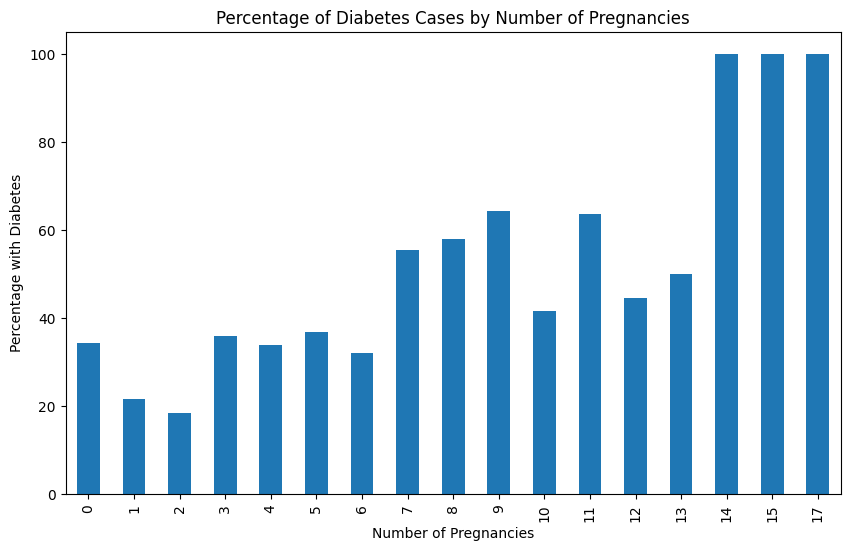

In [16]:
# решение
preg_diabetes = data.groupby('Pregnancies')['Class'].mean() * 100
plt.figure(figsize=(10, 6))
preg_diabetes.plot(kind='bar')
plt.title('Percentage of Diabetes Cases by Number of Pregnancies')
plt.xlabel('Number of Pregnancies')
plt.ylabel('Percentage with Diabetes')
plt.show()

__Задание 13.__

Добавьте новый бинарный признак:

__wasPregnant__ $\in$ {0,1} - была женщина беременна (1) или нет (0)

In [17]:
# решение
data['wasPregnant'] = (data['Pregnancies'] > 0).astype(int)


__Задание 14.__

Сравните процент больных диабетом среди женщин, которые были беременны и не были.

In [18]:
# решение
preg_diabetes_comp = data.groupby('wasPregnant')['Class'].mean() * 100
print("\nDiabetes percentage comparison:")
print(preg_diabetes_comp)



Diabetes percentage comparison:
wasPregnant
0    34.234234
1    35.007610
Name: Class, dtype: float64


__Задание 15.__

Добавьте новый категориальный признак __bodyType__ на основе столбца BMI:

__BMI Categories:__
    
Underweight = <18.5

Normal weight = 18.5–24.9

Overweight = 25–29.9

Obesity = BMI of 30 or greater

Признак должен принимать значения Underweight, Normal weight, Overweight и Obesity.

In [19]:
# решение
conditions = [
    (data['BMI'] < 18.5),
    (data['BMI'] >= 18.5) & (data['BMI'] < 25),
    (data['BMI'] >= 25) & (data['BMI'] < 30),
    (data['BMI'] >= 30)
]
choices = ['Underweight', 'Normal weight', 'Overweight', 'Obesity']
data['bodyType'] = np.select(conditions, choices)


__Задание 16.__

Какой процент женщин с нормальными показателями веса и давления больны диабетом?

In [20]:
# решение
normal_weight_pressure = data[
    (data['bodyType'] == 'Normal weight') & 
    (data['BloodPressure'] >= 80) & 
    (data['BloodPressure'] <= 89)
]
percentage_diabetes = (normal_weight_pressure['Class'].mean() * 100)
print(f"\nPercentage of women with normal weight and pressure who have diabetes: {percentage_diabetes:.2f}%") 


Percentage of women with normal weight and pressure who have diabetes: 10.00%
